In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


In [106]:
bins = pd.read_csv('SourceData/s2_binning_info.csv')
resp_nr = pd.read_csv('SourceData/s2_response_nr.csv')
resp_er = pd.read_csv('SourceData/s2_response_er.csv')
bg = pd.read_csv('SourceData/er_and_cevns_background.csv')
events = pd.read_csv('SourceData/events_after_cuts.csv')


In [107]:
#Exctract binning information
s2_bin_centers_log = bins['log_center_pe'].values
s2_bin_centers_lin = bins['linear_center_pe'].values
s2_bin_widths = (bins['end_pe'] - bins['start_pe']).values
s2_bin_edges = np.concatenate([bins['start_pe'].values, [bins['end_pe'].iloc[-1]]]) #start_pe contains all the edges except the last one, which we add with bins['end_pe'].iloc[-1]

In [108]:
#Exctracting information from nuclear recoil response
s2_energies = resp_nr['energy_kev'].values
bin_starts = resp_nr['energy_bin_start_kev'].values
bin_ends = resp_nr['energy_bin_end_kev'].values
dE = bin_ends - bin_starts

response_matrix_nr = resp_nr.values[:,3:] #we start from the 4th column, since the 3 previous ones are energies. The 4th column is s2_bin_000.

The Dark Matter model the authors use is a 4 GeV/c^2 spin-independent elastic WIMP spectrum which they compute using the wimprates package. We implement it below:


In [109]:
import wimprates as wr
reference_cross_section = 1e-45  # cm^2
rate_pertonneyearkev = wr.rate_wimp_std(
    es=s2_energies, 
    mw=4, 
    sigma_nucleon=reference_cross_section)


In [110]:
#Most of the code below was copied directly from the Public Data Release
rate_pertonneyear = rate_pertonneyearkev * dE
rate_before_cutoff = rate_pertonneyear * 0.97678 
#The authors of the paper remove events below 0.7keV
recoil_energy_cutoff_kev = 0.7
rate_after_cutoff = rate_before_cutoff.copy()

# Which bin contains the cutoff?
cutoff_bin_index = (bin_starts < recoil_energy_cutoff_kev).sum() - 1 #This counts how many bins start below 0.7 keV, then subtracts 1 to get the index

# All bins fully below 0.7 keV are removed
rate_after_cutoff[:cutoff_bin_index] = 0

# Suppress the spectrum proportionally in the bin with the cutoff
suppress_by = (
    (recoil_energy_cutoff_kev - bin_starts[cutoff_bin_index]) 
    / bin_starts[cutoff_bin_index])
assert 0 <= suppress_by <= 1

#Only keep the part above the cutoff
rate_after_cutoff[cutoff_bin_index] *= 1 - suppress_by 

The expected number of DM signals per S2 bin is given by the theoretical energy rate times the response matrix:

$$
s_i = \mathcal{E} \times \sum_j \left. \frac{dR}{dE} \right|_{E_j} \, \Delta E_j \, R_{ji}
$$

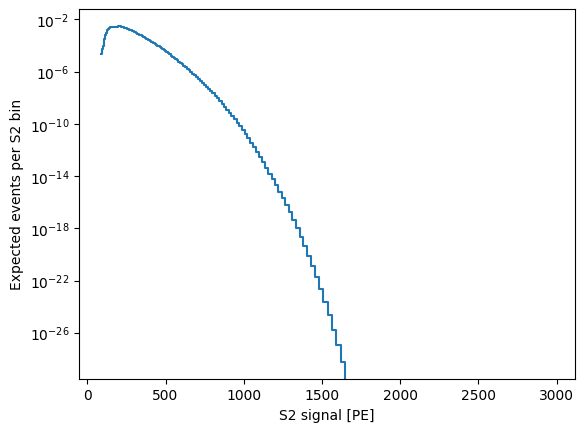

In [111]:
s_i = rate_after_cutoff @ response_matrix_nr
plt.plot(s2_bin_centers_log, s_i,drawstyle = 'steps-mid')
plt.xlabel("S2 signal [PE]")
plt.ylabel("Expected events per S2 bin")
plt.yscale('log')

In [ ]:
#The authors of the paper made a cut on the data and what survived are the potential events(which still may include background noise).
#This is what we excract below
k_obs, _ = np.histogram(events['s2_area_pe'].values, bins=s2_bin_edges) #np.histogram returns counts, bin_edges, but we only care about the counts. 
#k_obs[j] is the number of observed events in S2 bin j
#the s2_area_pe is the amount of photoelectron counts per S2 interval(hight x width = Area); they only care about events with S2 area between 90 and 3000PE
#that's where the cut comes from.

In [113]:
#Exctract background info
b_er = bg['er_background_events']
b_cevns = bg['cevns_background_events']
b_nominal = b_er + b_cevns